In [1]:
library(ggplot2)
library(dplyr)
library(cowplot)
library(gridExtra)
library(Seurat)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘cowplot’ was built under R version 4.3.2”

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.2”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
subclass_col <- readRDS("../../../04.data/04.config_files/color.subclass.rds")
subclass_col

CA1-ProS Glut         SUB-ProS Glut              Oligo NN 
            "#f173ac"             "#da765b"             "#3498db" 
     L2/3 IT RSP Glut               DG Glut           Astro-TE NN 
            "#89288F"             "#F47D2B"             "#65c294" 
             CA3 Glut             Sncg Gaba                OPC NN 
            "#8A9FD1"             "#C06CAB"             "#2585a6" 
     L2/3 IT CTX Glut       L4 RSP-ACA Glut        L5 ET CTX Glut 
            "#90D5E4"             "#ed1941"             "#b2d235" 
       L6 CT CTX Glut            Pvalb Gaba        L5 NP CTX Glut 
            "#3BBCA8"             "#FEE500"             "#61599d" 
       L5 IT CTX Glut    OB-STR-CTX Inh IMN              Sst Gaba 
            "#33a3dc"             "#DEA0FD"             "#FFB300" 
   ACB-BST-FS D1 Gaba          Microglia NN      OB-in Frmd7 Gaba 
            "#007947"             "#FF6800"             "#3283FE" 
           Lamp5 Gaba      L4/5 IT CTX Glut CLA-EPd-CTX Car3 Glut 
            "#00a6ac"             "#00538A"             "#8552a1" 
          STR D1 Gaba     OB-out Frmd7 Gaba  OB Eomes Ms4a15 Glut 
            "#FF8E00"             "#F4C800"             "#2ecc71" 
         OB Dopa-Gaba                OEC NN           STR D2 Gaba 
            "#f1c40f"             "#9b59b6"           "#11776CFF"

subclass_order <- unlist(strsplit("L2/3 IT CTX Glut
L4/5 IT CTX Glut
L5 IT CTX Glut
L2/3 IT RSP Glut
L4 RSP-ACA Glut
L5 ET CTX Glut
SUB-ProS Glut
CA1-ProS Glut
CA3 Glut
CLA-EPd-CTX Car3 Glut
L5 NP CTX Glut
L6 CT CTX Glut
DG Glut
OB Eomes Ms4a15 Glut
OB-in Frmd7 Gaba
OB-out Frmd7 Gaba
OB Dopa-Gaba
OB-STR-CTX Inh IMN
Sncg Gaba
Lamp5 Gaba
Pvalb Gaba
Sst Gaba
STR D1 Gaba
STR D2 Gaba
ACB-BST-FS D1 Gaba
Astro-TE NN
Oligo NN
OPC NN
Microglia NN","\n"))

In [ ]:
subclass_col <- subclass_col[subclass_order]

In [ ]:
H3K4me1_files <- list.files(paste0(indir,"/03_H3K4me1_Allsubclass/CA1/"), pattern = "*.tmp", full.names = TRUE)
H3K4me3_files <- list.files(paste0(indir,"/04_H3K4me3_Allsubclass/CA1/"), pattern = "*.tmp", full.names = TRUE)
H3K9me3_files <- list.files(paste0(indir,"/05_H3K9me3_Allsubclass/CA1/"), pattern = "*.tmp", full.names = TRUE)
H3K27ac_files <- list.files(paste0(indir,"/06_H3K27ac_Allsubclass/CA1/"), pattern = "*.tmp", full.names = TRUE)
H3K27me3_files <- list.files(paste0(indir,"/07_H3K27me3_Allsubclass/CA1/"), pattern = "*.tmp", full.names = TRUE)

H3K4me1_files;H3K4me3_files;H3K9me3_files;H3K27ac_files;H3K27me3_files

[1] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_CT.mm10.tmp"     
 [2] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L2_3.mm10.tmp"   
 [3] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L4_Rorb.mm10.tmp"
 [4] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L5.mm10.tmp"     
 [5] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L6.mm10.tmp"     
 [6] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_NP.mm10.tmp"     
 [7] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_CA1.mm10.tmp"    
 [8] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_CA23.mm10.tmp"   
 [9] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_DG.mm10.tmp"     
[10] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_CGE.mm10.tmp"    
[11] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_Pvalb.mm10.tmp"  
[12] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_Sst.mm10.tmp"

[1] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_CT.mm10.tmp"     
 [2] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L2_3.mm10.tmp"   
 [3] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L4_Rorb.mm10.tmp"
 [4] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L5.mm10.tmp"     
 [5] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L6.mm10.tmp"     
 [6] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_NP.mm10.tmp"     
 [7] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_HC_CA1.mm10.tmp"    
 [8] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_HC_CA23.mm10.tmp"   
 [9] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_HC_DG.mm10.tmp"     
[10] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_In_CGE.mm10.tmp"    
[11] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_In_Pvalb.mm10.tmp"  
[12] "../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_In_Sst.mm10.tmp"

[1] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_CT.mm10.tmp"     
 [2] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L2_3.mm10.tmp"   
 [3] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L4_Rorb.mm10.tmp"
 [4] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L5.mm10.tmp"     
 [5] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L6.mm10.tmp"     
 [6] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_NP.mm10.tmp"     
 [7] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_HC_CA1.mm10.tmp"    
 [8] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_HC_CA23.mm10.tmp"   
 [9] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_HC_DG.mm10.tmp"     
[10] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_In_CGE.mm10.tmp"    
[11] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_In_Pvalb.mm10.tmp"  
[12] "../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_In_Sst.mm10.tmp"

[1] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_CT.mm10.tmp"     
 [2] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L2_3.mm10.tmp"   
 [3] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L4_Rorb.mm10.tmp"
 [4] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L5.mm10.tmp"     
 [5] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L6.mm10.tmp"     
 [6] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_NP.mm10.tmp"     
 [7] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_HC_CA1.mm10.tmp"    
 [8] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_HC_CA23.mm10.tmp"   
 [9] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_HC_DG.mm10.tmp"     
[10] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_In_CGE.mm10.tmp"    
[11] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_In_Pvalb.mm10.tmp"  
[12] "../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_In_Sst.mm10.tmp"

[1] "../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L2_3.mm10.tmp"   
[2] "../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L4_Rorb.mm10.tmp"
[3] "../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L5.mm10.tmp"     
[4] "../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L6.mm10.tmp"     
[5] "../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_CA1.mm10.tmp"    
[6] "../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_CA23.mm10.tmp"   
[7] "../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_DG.mm10.tmp"     
[8] "../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_In_Pvalb.mm10.tmp"  
[9] "../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_In_Sst.mm10.tmp"

In [4]:
gsub(".*/|.tmp","",H3K4me1_files);gsub(".*/|.tmp","",H3K4me3_files)
gsub(".*/|.tmp","",H3K9me3_files);gsub(".*/|.tmp","",H3K27ac_files)
gsub(".*/|.tmp","",H3K27me3_files)

[1] "Paired-Tag_H3K4me1_FC_CT.mm10"      "Paired-Tag_H3K4me1_FC_L2_3.mm10"   
 [3] "Paired-Tag_H3K4me1_FC_L4_Rorb.mm10" "Paired-Tag_H3K4me1_FC_L5.mm10"     
 [5] "Paired-Tag_H3K4me1_FC_L6.mm10"      "Paired-Tag_H3K4me1_FC_NP.mm10"     
 [7] "Paired-Tag_H3K4me1_HC_CA1.mm10"     "Paired-Tag_H3K4me1_HC_CA23.mm10"   
 [9] "Paired-Tag_H3K4me1_HC_DG.mm10"      "Paired-Tag_H3K4me1_In_CGE.mm10"    
[11] "Paired-Tag_H3K4me1_In_Pvalb.mm10"   "Paired-Tag_H3K4me1_In_Sst.mm10"

[1] "Paired-Tag_H3K4me3_FC_CT.mm10"      "Paired-Tag_H3K4me3_FC_L2_3.mm10"   
 [3] "Paired-Tag_H3K4me3_FC_L4_Rorb.mm10" "Paired-Tag_H3K4me3_FC_L5.mm10"     
 [5] "Paired-Tag_H3K4me3_FC_L6.mm10"      "Paired-Tag_H3K4me3_FC_NP.mm10"     
 [7] "Paired-Tag_H3K4me3_HC_CA1.mm10"     "Paired-Tag_H3K4me3_HC_CA23.mm10"   
 [9] "Paired-Tag_H3K4me3_HC_DG.mm10"      "Paired-Tag_H3K4me3_In_CGE.mm10"    
[11] "Paired-Tag_H3K4me3_In_Pvalb.mm10"   "Paired-Tag_H3K4me3_In_Sst.mm10"

[1] "Paired-Tag_H3K9me3_FC_CT.mm10"      "Paired-Tag_H3K9me3_FC_L2_3.mm10"   
 [3] "Paired-Tag_H3K9me3_FC_L4_Rorb.mm10" "Paired-Tag_H3K9me3_FC_L5.mm10"     
 [5] "Paired-Tag_H3K9me3_FC_L6.mm10"      "Paired-Tag_H3K9me3_FC_NP.mm10"     
 [7] "Paired-Tag_H3K9me3_HC_CA1.mm10"     "Paired-Tag_H3K9me3_HC_CA23.mm10"   
 [9] "Paired-Tag_H3K9me3_HC_DG.mm10"      "Paired-Tag_H3K9me3_In_CGE.mm10"    
[11] "Paired-Tag_H3K9me3_In_Pvalb.mm10"   "Paired-Tag_H3K9me3_In_Sst.mm10"

[1] "Paired-Tag_H3K27ac_FC_CT.mm10"      "Paired-Tag_H3K27ac_FC_L2_3.mm10"   
 [3] "Paired-Tag_H3K27ac_FC_L4_Rorb.mm10" "Paired-Tag_H3K27ac_FC_L5.mm10"     
 [5] "Paired-Tag_H3K27ac_FC_L6.mm10"      "Paired-Tag_H3K27ac_FC_NP.mm10"     
 [7] "Paired-Tag_H3K27ac_HC_CA1.mm10"     "Paired-Tag_H3K27ac_HC_CA23.mm10"   
 [9] "Paired-Tag_H3K27ac_HC_DG.mm10"      "Paired-Tag_H3K27ac_In_CGE.mm10"    
[11] "Paired-Tag_H3K27ac_In_Pvalb.mm10"   "Paired-Tag_H3K27ac_In_Sst.mm10"

[1] "Paired-Tag_H3K27me3_FC_L2_3.mm10"    "Paired-Tag_H3K27me3_FC_L4_Rorb.mm10"
[3] "Paired-Tag_H3K27me3_FC_L5.mm10"      "Paired-Tag_H3K27me3_FC_L6.mm10"     
[5] "Paired-Tag_H3K27me3_HC_CA1.mm10"     "Paired-Tag_H3K27me3_HC_CA23.mm10"   
[7] "Paired-Tag_H3K27me3_HC_DG.mm10"      "Paired-Tag_H3K27me3_In_Pvalb.mm10"  
[9] "Paired-Tag_H3K27me3_In_Sst.mm10"

In [5]:
subclass_selectH3K4me1_col <- setNames(c("#3BBCA8","#90D5E4","#00538A","#33a3dc","#da765b","#61599d","#f173ac",
                                 "#8A9FD1","#F47D2B","#C06CAB","#FEE500","#FFB300"),
                               gsub(".*/|.tmp","",H3K4me1_files))
subclass_selectH3K4me1_col

Paired-Tag_H3K4me1_FC_CT.mm10    Paired-Tag_H3K4me1_FC_L2_3.mm10 
                         "#3BBCA8"                          "#90D5E4" 
Paired-Tag_H3K4me1_FC_L4_Rorb.mm10      Paired-Tag_H3K4me1_FC_L5.mm10 
                         "#00538A"                          "#33a3dc" 
     Paired-Tag_H3K4me1_FC_L6.mm10      Paired-Tag_H3K4me1_FC_NP.mm10 
                         "#da765b"                          "#61599d" 
    Paired-Tag_H3K4me1_HC_CA1.mm10    Paired-Tag_H3K4me1_HC_CA23.mm10 
                         "#f173ac"                          "#8A9FD1" 
     Paired-Tag_H3K4me1_HC_DG.mm10     Paired-Tag_H3K4me1_In_CGE.mm10 
                         "#F47D2B"                          "#C06CAB" 
  Paired-Tag_H3K4me1_In_Pvalb.mm10     Paired-Tag_H3K4me1_In_Sst.mm10 
                         "#FEE500"                          "#FFB300"

In [6]:
subclass_selectH3K4me3_col <- setNames(c("#3BBCA8","#90D5E4","#00538A","#33a3dc","#da765b","#61599d","#f173ac",
                                 "#8A9FD1","#F47D2B","#C06CAB","#FEE500","#FFB300"),
                               gsub(".*/|.tmp","",H3K4me3_files))
subclass_selectH3K4me3_col

Paired-Tag_H3K4me3_FC_CT.mm10    Paired-Tag_H3K4me3_FC_L2_3.mm10 
                         "#3BBCA8"                          "#90D5E4" 
Paired-Tag_H3K4me3_FC_L4_Rorb.mm10      Paired-Tag_H3K4me3_FC_L5.mm10 
                         "#00538A"                          "#33a3dc" 
     Paired-Tag_H3K4me3_FC_L6.mm10      Paired-Tag_H3K4me3_FC_NP.mm10 
                         "#da765b"                          "#61599d" 
    Paired-Tag_H3K4me3_HC_CA1.mm10    Paired-Tag_H3K4me3_HC_CA23.mm10 
                         "#f173ac"                          "#8A9FD1" 
     Paired-Tag_H3K4me3_HC_DG.mm10     Paired-Tag_H3K4me3_In_CGE.mm10 
                         "#F47D2B"                          "#C06CAB" 
  Paired-Tag_H3K4me3_In_Pvalb.mm10     Paired-Tag_H3K4me3_In_Sst.mm10 
                         "#FEE500"                          "#FFB300"

In [7]:
subclass_selectH3K9me3_col <- setNames(c("#3BBCA8","#90D5E4","#00538A","#33a3dc","#da765b","#61599d","#f173ac",
                                 "#8A9FD1","#F47D2B","#C06CAB","#FEE500","#FFB300"),
                               gsub(".*/|.tmp","",H3K9me3_files))
subclass_selectH3K9me3_col

Paired-Tag_H3K9me3_FC_CT.mm10    Paired-Tag_H3K9me3_FC_L2_3.mm10 
                         "#3BBCA8"                          "#90D5E4" 
Paired-Tag_H3K9me3_FC_L4_Rorb.mm10      Paired-Tag_H3K9me3_FC_L5.mm10 
                         "#00538A"                          "#33a3dc" 
     Paired-Tag_H3K9me3_FC_L6.mm10      Paired-Tag_H3K9me3_FC_NP.mm10 
                         "#da765b"                          "#61599d" 
    Paired-Tag_H3K9me3_HC_CA1.mm10    Paired-Tag_H3K9me3_HC_CA23.mm10 
                         "#f173ac"                          "#8A9FD1" 
     Paired-Tag_H3K9me3_HC_DG.mm10     Paired-Tag_H3K9me3_In_CGE.mm10 
                         "#F47D2B"                          "#C06CAB" 
  Paired-Tag_H3K9me3_In_Pvalb.mm10     Paired-Tag_H3K9me3_In_Sst.mm10 
                         "#FEE500"                          "#FFB300"

In [8]:
subclass_selectH3K27ac_col <- setNames(c("#3BBCA8","#90D5E4","#00538A","#33a3dc","#da765b","#61599d","#f173ac",
                                 "#8A9FD1","#F47D2B","#C06CAB","#FEE500","#FFB300"),
                               gsub(".*/|.tmp","",H3K27ac_files))
subclass_selectH3K27ac_col

Paired-Tag_H3K27ac_FC_CT.mm10    Paired-Tag_H3K27ac_FC_L2_3.mm10 
                         "#3BBCA8"                          "#90D5E4" 
Paired-Tag_H3K27ac_FC_L4_Rorb.mm10      Paired-Tag_H3K27ac_FC_L5.mm10 
                         "#00538A"                          "#33a3dc" 
     Paired-Tag_H3K27ac_FC_L6.mm10      Paired-Tag_H3K27ac_FC_NP.mm10 
                         "#da765b"                          "#61599d" 
    Paired-Tag_H3K27ac_HC_CA1.mm10    Paired-Tag_H3K27ac_HC_CA23.mm10 
                         "#f173ac"                          "#8A9FD1" 
     Paired-Tag_H3K27ac_HC_DG.mm10     Paired-Tag_H3K27ac_In_CGE.mm10 
                         "#F47D2B"                          "#C06CAB" 
  Paired-Tag_H3K27ac_In_Pvalb.mm10     Paired-Tag_H3K27ac_In_Sst.mm10 
                         "#FEE500"                          "#FFB300"

In [9]:
subclass_selectH3K27me3_col <- setNames(c("#90D5E4","#00538A","#33a3dc","#da765b","#f173ac",
                                 "#8A9FD1","#F47D2B","#FEE500","#FFB300"),
                               gsub(".*/|.tmp","",H3K27me3_files))
subclass_selectH3K27me3_col

Paired-Tag_H3K27me3_FC_L2_3.mm10 Paired-Tag_H3K27me3_FC_L4_Rorb.mm10 
                          "#90D5E4"                           "#00538A" 
     Paired-Tag_H3K27me3_FC_L5.mm10      Paired-Tag_H3K27me3_FC_L6.mm10 
                          "#33a3dc"                           "#da765b" 
    Paired-Tag_H3K27me3_HC_CA1.mm10    Paired-Tag_H3K27me3_HC_CA23.mm10 
                          "#f173ac"                           "#8A9FD1" 
     Paired-Tag_H3K27me3_HC_DG.mm10   Paired-Tag_H3K27me3_In_Pvalb.mm10 
                          "#F47D2B"                           "#FEE500" 
    Paired-Tag_H3K27me3_In_Sst.mm10 
                          "#FFB300"

In [ ]:
process_files_modification <- function(modification_dir, label, Histone_modification, name, subclass_col) { # "../output/03_H3K4me1_Allsubclass/CA1/"),"CA1-ProS Glut (DHMR)","H3K4me1","Paired-Tag_H3K4me1_HC_CA1.mm10",subclass_selectH3K4me1_col
  
  modification_files <- list.files(modification_dir, pattern = "*.tmp", full.names = TRUE)
  
  common_names_modification <- gsub(".tmp", "", basename(modification_files))
  
  all_modification_data <- data.frame()
  
  for (common_name in common_names_modification) {
    modification_file <- modification_files[grep(common_name, common_names_modification)]
      
    if (length(modification_file) > 0) {
        
      modification_data <- read.csv(modification_file, sep = "\t", check.names = F) %>% 
        mutate(pos = as.numeric(rownames(.)))
        
      print(paste(sprintf("Processing %s file:",Histone_modification), modification_file))
      print(colnames(modification_data))
        
      modification_colname <- common_name
        
      if (modification_colname %in% colnames(modification_data)) {
        modification_data <- modification_data %>% 
          dplyr::select(value = !!modification_colname, pos) %>% 
          mutate(SeqType = Histone_modification, File = common_name)
      } else {
        warning(paste("Column", modification_colname, "not found in", modification_file))
        next
      }
        
      all_modification_data <- rbind(all_modification_data, modification_data)
      
    } else {
      warning(paste("No matching file found for:", common_name))
    }
  }
  
  col <- c(subclass_col[name],
  setNames(rep("lightgrey",length(names(subclass_col)[names(subclass_col) != name])),
           names(subclass_col)[names(subclass_col) != name]))
  
  if (nrow(all_modification_data) > 0) {
    p <- ggplot(all_modification_data, aes(x = pos, y = value, color = File, group = File)) + 
#       geom_line(alpha = 1, linewidth = 1) +
#       geom_line(aes(linewidth = ifelse(File == name, 1.5, 0.8)), alpha = 1) +
      geom_line(data = subset(all_modification_data, File == name), size = 2, alpha = 1) +  # 带颜色的线条
      geom_line(data = subset(all_modification_data, File != name), size = 1, alpha = 1) +  # 灰色线条
      xlab(label) +
      ylab("Mean signal") +
#       scale_color_manual(values = scales::hue_pal()(length(unique(all_modification_data$File)))) +
      scale_color_manual(values = col) +
      scale_x_continuous(breaks=c(1,100,200),
                     labels=c("-3kb","center","+3kb"))+
      scale_y_continuous(labels = scales::number_format(accuracy = 0.01)) +  # 设置保留两位小数
      ggtitle(Histone_modification) +
      theme_bw() +
      theme(
        legend.position = "top",
        legend.text = element_text(size = 18, family = "ArialMT"),
        legend.title = element_blank(),
        plot.title = element_text(hjust = 0.5, size = 20, family = "ArialMT"),
        axis.title.x = element_text(color = "black", size = 18, family = "ArialMT"),
        axis.title.y = element_text(color = "black", size = 18, family = "ArialMT"),
        axis.text.x = element_text(color = "black", size = 16, family = "ArialMT"),
        axis.text.y = element_text(color = "black", size = 16, family = "ArialMT"),
        axis.line = element_line(size = 0.8),
        axis.ticks = element_line(size = 0.8),
        panel.border = element_rect(color = "black", size = 1.2, linetype = "solid"),
        panel.grid = element_blank()) +
      guides(linewidth = "none") 
    
    p_no_legend <- p + theme(legend.position = "none")
    return(p_no_legend)
    
#     output_pdf <- file.path(output_dir, sprintf("%s_merged_plot.pdf",Histone_modification))
#     ggsave(output_pdf, plot = p, width = 8, height = 5)
  } else {
    warning(sprintf("No %s data to plot.",Histone_modification))
  }
}

In [ ]:
dir.create(paste0(indir,"/09_plot"))

In [ ]:
CA1_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/CA1/"),) "CA1-ProS Glut (DHMR)", "H3K4me1", "Paired-Tag_H3K4me1_HC_CA1.mm10", subclass_selectH3K4me1_col)

[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_CT.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L5.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L6.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_NP.mm10.tmp"
[1] "Paired-Tag_H3K4m

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


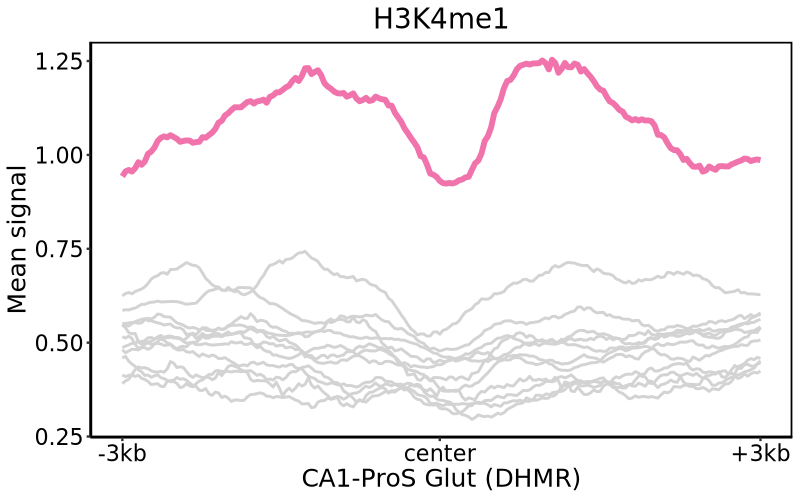

In [13]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 100)
CA1_H3K4me1

In [ ]:
H3K4me1_files;H3K4me3_files;H3K9me3_files;H3K27ac_files;H3K27me3_files

In [14]:
H3K4me1_files

[1] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_CT.mm10.tmp"     
 [2] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L2_3.mm10.tmp"   
 [3] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L4_Rorb.mm10.tmp"
 [4] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L5.mm10.tmp"     
 [5] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L6.mm10.tmp"     
 [6] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_NP.mm10.tmp"     
 [7] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_CA1.mm10.tmp"    
 [8] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_CA23.mm10.tmp"   
 [9] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_DG.mm10.tmp"     
[10] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_CGE.mm10.tmp"    
[11] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_Pvalb.mm10.tmp"  
[12] "../output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_Sst.mm10.tmp"

In [ ]:
CA23_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/CA23/"),
                                          "CA3 Glut (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_HC_CA23.mm10",
                                          subclass_selectH3K4me1_col)

CT_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/CT/"),
                                          "L6 CT CTX Glut (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_FC_CT.mm10",
                                          subclass_selectH3K4me1_col)

DG_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/DG/"),
                                          "DG Glut (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_HC_DG.mm10",
                                          subclass_selectH3K4me1_col)

L2_3_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/L2_3/"),
                                          "L2/3 IT CTX Glut (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_FC_L2_3.mm10",
                                          subclass_selectH3K4me1_col)

L4_5_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/L4_5/"),
                                          "L4/5 IT CTX Glut (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_FC_L4_Rorb.mm10",
                                          subclass_selectH3K4me1_col)

L5_H3K4me1_1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/L5/"),
                                          "L5 IT CTX Glut (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_FC_L5.mm10",
                                          subclass_selectH3K4me1_col)

L5_H3K4me1_2 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/L5/"),
                                          "L5 IT CTX Glut (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_FC_L6.mm10",
                                          subclass_selectH3K4me1_col)

Lamp5_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/Lamp5/"),
                                          "Lamp5 Gaba (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_In_CGE.mm10",
                                          subclass_selectH3K4me1_col)

NP_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/NP/"),
                                          "L5 NP CTX Glut (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_FC_NP.mm10",
                                          subclass_selectH3K4me1_col)

Pvalb_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/Pvalb/"),
                                          "Pvalb Gaba (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_In_Pvalb.mm10",
                                          subclass_selectH3K4me1_col)

Sncg_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/Sncg/"),
                                          "Sncg Gaba (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_In_CGE.mm10",
                                          subclass_selectH3K4me1_col)

Sst_H3K4me1 <- process_files_modification(paste0(indir,"/03_H3K4me1_Allsubclass/Sst/"),
                                          "Sst Gaba (DHMR)",
                                          "H3K4me1",
                                          "Paired-Tag_H3K4me1_In_Sst.mm10",
                                          subclass_selectH3K4me1_col)

[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA23//Paired-Tag_H3K4me1_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_CT.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA23//Paired-Tag_H3K4me1_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA23//Paired-Tag_H3K4me1_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA23//Paired-Tag_H3K4me1_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L5.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA23//Paired-Tag_H3K4me1_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L6.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/CA23//Paired-Tag_H3K4me1_FC_NP.mm10.tmp"
[1] "Paired-Tag

[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/L4_5//Paired-Tag_H3K4me1_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_CT.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/L4_5//Paired-Tag_H3K4me1_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/L4_5//Paired-Tag_H3K4me1_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/L4_5//Paired-Tag_H3K4me1_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L5.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/L4_5//Paired-Tag_H3K4me1_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L6.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/L4_5//Paired-Tag_H3K4me1_FC_NP.mm10.tmp"
[1] "Paired-Tag

[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/NP//Paired-Tag_H3K4me1_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_CT.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/NP//Paired-Tag_H3K4me1_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/NP//Paired-Tag_H3K4me1_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/NP//Paired-Tag_H3K4me1_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L5.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/NP//Paired-Tag_H3K4me1_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_L6.mm10" "pos"                          
[1] "Processing H3K4me1 file: ../output/03_H3K4me1_Allsubclass/NP//Paired-Tag_H3K4me1_FC_NP.mm10.tmp"
[1] "Paired-Tag_H3K4me1_FC_

In [16]:
g1 <- arrangeGrob(CA1_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g2 <- arrangeGrob(CA23_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g3 <- arrangeGrob(CT_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g4 <- arrangeGrob(DG_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g5 <- arrangeGrob(L2_3_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g6 <- arrangeGrob(L4_5_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g7 <- arrangeGrob(L5_H3K4me1_1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g8 <- arrangeGrob(L5_H3K4me1_2, heights = unit(5, "inches"), widths = unit(8, "inches"))
g9 <- arrangeGrob(Lamp5_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g10 <- arrangeGrob(NP_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g11 <- arrangeGrob(Pvalb_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g12 <- arrangeGrob(Sncg_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))
g13 <- arrangeGrob(Sst_H3K4me1, heights = unit(5, "inches"), widths = unit(8, "inches"))

In [17]:
combined_plot_H3K4me1 <- arrangeGrob(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10, g11, g12, g13, ncol = 5, nrow = 3)

In [ ]:
ggsave("../../../output/01.Young_Mouse/07-Histone/02-lineplot/H3K4me1_allsubclass.pdf", combined_plot_H3K4me1, width = 40, height = 15)

In [ ]:
CA1_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/CA1/"),
                                          "CA1-ProS Glut (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_HC_CA1.mm10",
                                          subclass_selectH3K4me3_col)

CA23_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/CA23/"),
                                          "CA3 Glut (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_HC_CA23.mm10",
                                          subclass_selectH3K4me3_col)

CT_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/CT/"),
                                          "L6 CT CTX Glut (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_FC_CT.mm10",
                                          subclass_selectH3K4me3_col)

DG_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/DG/"),
                                          "DG Glut (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_HC_DG.mm10",
                                          subclass_selectH3K4me3_col)

L2_3_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/L2_3/"),
                                          "L2/3 IT CTX Glut (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_FC_L2_3.mm10",
                                          subclass_selectH3K4me3_col)

L4_5_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/L4_5/"),
                                          "L4/5 IT CTX Glut (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_FC_L4_Rorb.mm10",
                                          subclass_selectH3K4me3_col)

L5_H3K4me3_1 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/L5/"),
                                          "L5 IT CTX Glut (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_FC_L5.mm10",
                                          subclass_selectH3K4me3_col)

L5_H3K4me3_2 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/L5/"),
                                          "L5 IT CTX Glut (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_FC_L6.mm10",
                                          subclass_selectH3K4me3_col)

Lamp5_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/Lamp5/"),
                                          "Lamp5 Gaba (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_In_CGE.mm10",
                                          subclass_selectH3K4me3_col)

NP_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/NP/"),
                                          "L5 NP CTX Glut (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_FC_NP.mm10",
                                          subclass_selectH3K4me3_col)

Pvalb_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/Pvalb/"),
                                          "Pvalb Gaba (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_In_Pvalb.mm10",
                                          subclass_selectH3K4me3_col)

Sncg_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/Sncg/"),
                                          "Sncg Gaba (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_In_CGE.mm10",
                                          subclass_selectH3K4me3_col)

Sst_H3K4me3 <- process_files_modification(paste0(indir,"/04_H3K4me3_Allsubclass/Sst/"),
                                          "Sst Gaba (DHMR)",
                                          "H3K4me3",
                                          "Paired-Tag_H3K4me3_In_Sst.mm10",
                                          subclass_selectH3K4me3_col)

[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_CT.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L5.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L6.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_NP.mm10.tmp"
[1] "Paired-Tag_H3K4m

[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/L2_3//Paired-Tag_H3K4me3_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_CT.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/L2_3//Paired-Tag_H3K4me3_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/L2_3//Paired-Tag_H3K4me3_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/L2_3//Paired-Tag_H3K4me3_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L5.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/L2_3//Paired-Tag_H3K4me3_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L6.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/L2_3//Paired-Tag_H3K4me3_FC_NP.mm10.tmp"
[1] "Paired-Tag

[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Lamp5//Paired-Tag_H3K4me3_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_CT.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Lamp5//Paired-Tag_H3K4me3_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Lamp5//Paired-Tag_H3K4me3_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Lamp5//Paired-Tag_H3K4me3_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L5.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Lamp5//Paired-Tag_H3K4me3_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L6.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Lamp5//Paired-Tag_H3K4me3_FC_NP.mm10.tmp"
[1] "Pair

[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Sst//Paired-Tag_H3K4me3_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_CT.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Sst//Paired-Tag_H3K4me3_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Sst//Paired-Tag_H3K4me3_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Sst//Paired-Tag_H3K4me3_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L5.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Sst//Paired-Tag_H3K4me3_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K4me3_FC_L6.mm10" "pos"                          
[1] "Processing H3K4me3 file: ../output/04_H3K4me3_Allsubclass/Sst//Paired-Tag_H3K4me3_FC_NP.mm10.tmp"
[1] "Paired-Tag_H3K4m

In [20]:
gg1 <- arrangeGrob(CA1_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg2 <- arrangeGrob(CA23_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg3 <- arrangeGrob(CT_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg4 <- arrangeGrob(DG_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg5 <- arrangeGrob(L2_3_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg6 <- arrangeGrob(L4_5_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg7 <- arrangeGrob(L5_H3K4me3_1, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg8 <- arrangeGrob(L5_H3K4me3_2, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg9 <- arrangeGrob(Lamp5_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg10 <- arrangeGrob(NP_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg11 <- arrangeGrob(Pvalb_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg12 <- arrangeGrob(Sncg_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
gg13 <- arrangeGrob(Sst_H3K4me3, heights = unit(5, "inches"), widths = unit(8, "inches"))

In [21]:
combined_plot_H3K4me3 <- arrangeGrob(gg1, gg2, gg3, gg4, gg5, gg6, gg7, gg8, gg9, gg10, gg11, gg12, gg13, ncol = 5, nrow = 3)

In [ ]:
ggsave("../../../output/01.Young_Mouse/07-Histone/02-lineplot/H3K4me3_allsubclass.pdf", combined_plot_H3K4me3, width = 40, height = 15)

In [ ]:
CA1_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/CA1/"),
                                          "CA1-ProS Glut (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_HC_CA1.mm10",
                                          subclass_selectH3K9me3_col)

CA23_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/CA23/"),
                                          "CA3 Glut (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_HC_CA23.mm10",
                                          subclass_selectH3K9me3_col)

CT_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/CT/"),
                                          "L6 CT CTX Glut (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_FC_CT.mm10",
                                          subclass_selectH3K9me3_col)

DG_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/DG/"),
                                          "DG Glut (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_HC_DG.mm10",
                                          subclass_selectH3K9me3_col)

L2_3_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/L2_3/"),
                                          "L2/3 IT CTX Glut (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_FC_L2_3.mm10",
                                          subclass_selectH3K9me3_col)

L4_5_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/L4_5/"),
                                          "L4/5 IT CTX Glut (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_FC_L4_Rorb.mm10",
                                          subclass_selectH3K9me3_col)

L5_H3K9me3_1 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/L5/"),
                                          "L5 IT CTX Glut (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_FC_L5.mm10",
                                          subclass_selectH3K9me3_col)

L5_H3K9me3_2 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/L5/"),
                                          "L5 IT CTX Glut (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_FC_L6.mm10",
                                          subclass_selectH3K9me3_col)

Lamp5_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/Lamp5/"),
                                          "Lamp5 Gaba (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_In_CGE.mm10",
                                          subclass_selectH3K9me3_col)

NP_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/NP/"),
                                          "L5 NP CTX Glut (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_FC_NP.mm10",
                                          subclass_selectH3K9me3_col)

Pvalb_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/Pvalb/"),
                                          "Pvalb Gaba (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_In_Pvalb.mm10",
                                          subclass_selectH3K9me3_col)

Sncg_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/Sncg/"),
                                          "Sncg Gaba (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_In_CGE.mm10",
                                          subclass_selectH3K9me3_col)

Sst_H3K9me3 <- process_files_modification(paste0(indir,"/05_H3K9me3_Allsubclass/Sst/"),
                                          "Sst Gaba (DHMR)",
                                          "H3K9me3",
                                          "Paired-Tag_H3K9me3_In_Sst.mm10",
                                          subclass_selectH3K9me3_col)

[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_CT.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L5.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L6.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_NP.mm10.tmp"
[1] "Paired-Tag_H3K9m

[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/L2_3//Paired-Tag_H3K9me3_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_CT.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/L2_3//Paired-Tag_H3K9me3_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/L2_3//Paired-Tag_H3K9me3_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/L2_3//Paired-Tag_H3K9me3_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L5.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/L2_3//Paired-Tag_H3K9me3_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L6.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/L2_3//Paired-Tag_H3K9me3_FC_NP.mm10.tmp"
[1] "Paired-Tag

[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Lamp5//Paired-Tag_H3K9me3_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_CT.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Lamp5//Paired-Tag_H3K9me3_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Lamp5//Paired-Tag_H3K9me3_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Lamp5//Paired-Tag_H3K9me3_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L5.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Lamp5//Paired-Tag_H3K9me3_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L6.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Lamp5//Paired-Tag_H3K9me3_FC_NP.mm10.tmp"
[1] "Pair

[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Sst//Paired-Tag_H3K9me3_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_CT.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Sst//Paired-Tag_H3K9me3_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Sst//Paired-Tag_H3K9me3_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Sst//Paired-Tag_H3K9me3_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L5.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Sst//Paired-Tag_H3K9me3_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K9me3_FC_L6.mm10" "pos"                          
[1] "Processing H3K9me3 file: ../output/05_H3K9me3_Allsubclass/Sst//Paired-Tag_H3K9me3_FC_NP.mm10.tmp"
[1] "Paired-Tag_H3K9m

In [24]:
ggg1 <- arrangeGrob(CA1_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg2 <- arrangeGrob(CA23_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg3 <- arrangeGrob(CT_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg4 <- arrangeGrob(DG_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg5 <- arrangeGrob(L2_3_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg6 <- arrangeGrob(L4_5_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg7 <- arrangeGrob(L5_H3K9me3_1, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg8 <- arrangeGrob(L5_H3K9me3_2, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg9 <- arrangeGrob(Lamp5_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg10 <- arrangeGrob(NP_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg11 <- arrangeGrob(Pvalb_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg12 <- arrangeGrob(Sncg_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggg13 <- arrangeGrob(Sst_H3K9me3, heights = unit(5, "inches"), widths = unit(8, "inches"))

In [25]:
combined_plot_H3K9me3 <- arrangeGrob(ggg1, ggg2, ggg3, ggg4, ggg5, ggg6, ggg7, ggg8, ggg9, ggg10, ggg11, ggg12, ggg13, ncol = 5, nrow = 3)

In [ ]:
ggsave("../../../output/01.Young_Mouse/07-Histone/02-lineplot/H3K9me3_allsubclass.pdf", combined_plot_H3K9me3, width = 40, height = 15)

In [ ]:
CA1_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/CA1/"),
                                          "CA1-ProS Glut (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_HC_CA1.mm10",
                                          subclass_selectH3K27ac_col)

CA23_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/CA23/"),
                                          "CA3 Glut (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_HC_CA23.mm10",
                                          subclass_selectH3K27ac_col)

CT_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/CT/"),
                                          "L6 CT CTX Glut (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_FC_CT.mm10",
                                          subclass_selectH3K27ac_col)

DG_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/DG/"),
                                          "DG Glut (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_HC_DG.mm10",
                                          subclass_selectH3K27ac_col)

L2_3_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/L2_3/"),
                                          "L2/3 IT CTX Glut (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_FC_L2_3.mm10",
                                          subclass_selectH3K27ac_col)

L4_5_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/L4_5/"),
                                          "L4/5 IT CTX Glut (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_FC_L4_Rorb.mm10",
                                          subclass_selectH3K27ac_col)

L5_H3K27ac_1 <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/L5/"),
                                          "L5 IT CTX Glut (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_FC_L5.mm10",
                                          subclass_selectH3K27ac_col)

L5_H3K27ac_2 <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/L5/"),
                                          "L5 IT CTX Glut (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_FC_L6.mm10",
                                          subclass_selectH3K27ac_col)

Lamp5_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/Lamp5/"),
                                          "Lamp5 Gaba (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_In_CGE.mm10",
                                          subclass_selectH3K27ac_col)

NP_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/NP/"),
                                          "L5 NP CTX Glut (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_FC_NP.mm10",
                                          subclass_selectH3K27ac_col)

Pvalb_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/Pvalb/"),
                                          "Pvalb Gaba (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_In_Pvalb.mm10",
                                          subclass_selectH3K27ac_col)

Sncg_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/Sncg/"),
                                          "Sncg Gaba (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_In_CGE.mm10",
                                          subclass_selectH3K27ac_col)

Sst_H3K27ac <- process_files_modification(paste0(indir,"/06_H3K27ac_Allsubclass/Sst/"),
                                          "Sst Gaba (DHMR)",
                                          "H3K27ac",
                                          "Paired-Tag_H3K27ac_In_Sst.mm10",
                                          subclass_selectH3K27ac_col)

[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_CT.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L5.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L6.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_NP.mm10.tmp"
[1] "Paired-Tag_H3K27

[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/L2_3//Paired-Tag_H3K27ac_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_CT.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/L2_3//Paired-Tag_H3K27ac_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/L2_3//Paired-Tag_H3K27ac_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/L2_3//Paired-Tag_H3K27ac_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L5.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/L2_3//Paired-Tag_H3K27ac_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L6.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/L2_3//Paired-Tag_H3K27ac_FC_NP.mm10.tmp"
[1] "Paired-Tag

[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Lamp5//Paired-Tag_H3K27ac_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_CT.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Lamp5//Paired-Tag_H3K27ac_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Lamp5//Paired-Tag_H3K27ac_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Lamp5//Paired-Tag_H3K27ac_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L5.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Lamp5//Paired-Tag_H3K27ac_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L6.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Lamp5//Paired-Tag_H3K27ac_FC_NP.mm10.tmp"
[1] "Pair

[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Sst//Paired-Tag_H3K27ac_FC_CT.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_CT.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Sst//Paired-Tag_H3K27ac_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L2_3.mm10" "pos"                            
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Sst//Paired-Tag_H3K27ac_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L4_Rorb.mm10" "pos"                               
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Sst//Paired-Tag_H3K27ac_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L5.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Sst//Paired-Tag_H3K27ac_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K27ac_FC_L6.mm10" "pos"                          
[1] "Processing H3K27ac file: ../output/06_H3K27ac_Allsubclass/Sst//Paired-Tag_H3K27ac_FC_NP.mm10.tmp"
[1] "Paired-Tag_H3K27

In [28]:
gggg1 <- arrangeGrob(CA1_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg2 <- arrangeGrob(CA23_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg3 <- arrangeGrob(CT_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg4 <- arrangeGrob(DG_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg5 <- arrangeGrob(L2_3_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg6 <- arrangeGrob(L4_5_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg7 <- arrangeGrob(L5_H3K27ac_1, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg8 <- arrangeGrob(L5_H3K27ac_2, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg9 <- arrangeGrob(Lamp5_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg10 <- arrangeGrob(NP_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg11 <- arrangeGrob(Pvalb_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg12 <- arrangeGrob(Sncg_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))
gggg13 <- arrangeGrob(Sst_H3K27ac, heights = unit(5, "inches"), widths = unit(8, "inches"))

In [29]:
combined_plot_H3K27ac <- arrangeGrob(gggg1, gggg2, gggg3, gggg4, gggg5, gggg6, gggg7, gggg8, gggg9, gggg10, gggg11, gggg12, gggg13, ncol = 5, nrow = 3)

In [ ]:
ggsave("../../../output/01.Young_Mouse/07-Histone/02-lineplot/H3K27ac_allsubclass.pdf", combined_plot_H3K27ac, width = 40, height = 15)

In [ ]:
CA1_H3K27me3 <- process_files_modification(paste0(indir,"/07_H3K27me3_Allsubclass/CA1/"),
                                          "CA1-ProS Glut (DHMR)",
                                          "H3K27me3",
                                          "Paired-Tag_H3K27me3_HC_CA1.mm10",
                                          subclass_selectH3K27me3_col)

CA23_H3K27me3 <- process_files_modification(paste0(indir,"/07_H3K27me3_Allsubclass/CA23/"),
                                          "CA3 Glut (DHMR)",
                                          "H3K27me3",
                                          "Paired-Tag_H3K27me3_HC_CA23.mm10",
                                          subclass_selectH3K27me3_col)

DG_H3K27me3 <- process_files_modification(paste0(indir,"/07_H3K27me3_Allsubclass/DG/"),
                                          "DG Glut (DHMR)",
                                          "H3K27me3",
                                          "Paired-Tag_H3K27me3_HC_DG.mm10",
                                          subclass_selectH3K27me3_col)

L2_3_H3K27me3 <- process_files_modification(paste0(indir,"/07_H3K27me3_Allsubclass/L2_3/"),
                                          "L2/3 IT CTX Glut (DHMR)",
                                          "H3K27me3",
                                          "Paired-Tag_H3K27me3_FC_L2_3.mm10",
                                          subclass_selectH3K27me3_col)

L4_5_H3K27me3 <- process_files_modification(paste0(indir,"/07_H3K27me3_Allsubclass/L4_5/"),
                                          "L4/5 IT CTX Glut (DHMR)",
                                          "H3K27me3",
                                          "Paired-Tag_H3K27me3_FC_L4_Rorb.mm10",
                                          subclass_selectH3K27me3_col)

L5_H3K27me3_1 <- process_files_modification(paste0(indir,"/07_H3K27me3_Allsubclass/L5/"),
                                          "L5 IT CTX Glut (DHMR)",
                                          "H3K27me3",
                                          "Paired-Tag_H3K27me3_FC_L5.mm10",
                                          subclass_selectH3K27me3_col)

L5_H3K27me3_2 <- process_files_modification(paste0(indir,"/07_H3K27me3_Allsubclass/L5/"),
                                          "L5 IT CTX Glut (DHMR)",
                                          "H3K27me3",
                                          "Paired-Tag_H3K27me3_FC_L6.mm10",
                                          subclass_selectH3K27me3_col)

Pvalb_H3K27me3 <- process_files_modification(paste0(indir,"/07_H3K27me3_Allsubclass/Pvalb/"),
                                          "Pvalb Gaba (DHMR)",
                                          "H3K27me3",
                                          "Paired-Tag_H3K27me3_In_Pvalb.mm10",
                                          subclass_selectH3K27me3_col)

Sst_H3K27me3 <- process_files_modification(paste0(indir,"/07_H3K27me3_Allsubclass/Sst/"),
                                          "Sst Gaba (DHMR)",
                                          "H3K27me3",
                                          "Paired-Tag_H3K27me3_In_Sst.mm10",
                                          subclass_selectH3K27me3_col)

[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K27me3_FC_L2_3.mm10" "pos"                             
[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K27me3_FC_L4_Rorb.mm10" "pos"                                
[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K27me3_FC_L5.mm10" "pos"                           
[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K27me3_FC_L6.mm10" "pos"                           
[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_CA1.mm10.tmp"
[1] "Paired-Tag_H3K27me3_HC_CA1.mm10" "pos"                            
[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_CA2

[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/L5//Paired-Tag_H3K27me3_FC_L2_3.mm10.tmp"
[1] "Paired-Tag_H3K27me3_FC_L2_3.mm10" "pos"                             
[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/L5//Paired-Tag_H3K27me3_FC_L4_Rorb.mm10.tmp"
[1] "Paired-Tag_H3K27me3_FC_L4_Rorb.mm10" "pos"                                
[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/L5//Paired-Tag_H3K27me3_FC_L5.mm10.tmp"
[1] "Paired-Tag_H3K27me3_FC_L5.mm10" "pos"                           
[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/L5//Paired-Tag_H3K27me3_FC_L6.mm10.tmp"
[1] "Paired-Tag_H3K27me3_FC_L6.mm10" "pos"                           
[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/L5//Paired-Tag_H3K27me3_HC_CA1.mm10.tmp"
[1] "Paired-Tag_H3K27me3_HC_CA1.mm10" "pos"                            
[1] "Processing H3K27me3 file: ../output/07_H3K27me3_Allsubclass/L5//Paired-Tag_H3K27me3_HC_CA23.mm10

In [32]:
ggggg1 <- arrangeGrob(CA1_H3K27me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggggg2 <- arrangeGrob(CA23_H3K27me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggggg3 <- arrangeGrob(DG_H3K27me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggggg4 <- arrangeGrob(L2_3_H3K27me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggggg5 <- arrangeGrob(L4_5_H3K27me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggggg6 <- arrangeGrob(L5_H3K27me3_1, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggggg7 <- arrangeGrob(L5_H3K27me3_2, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggggg8 <- arrangeGrob(Pvalb_H3K27me3, heights = unit(5, "inches"), widths = unit(8, "inches"))
ggggg9 <- arrangeGrob(Sst_H3K27me3, heights = unit(5, "inches"), widths = unit(8, "inches"))

In [33]:
combined_plot_H3K27me3 <- arrangeGrob(ggggg1, ggggg2, ggggg3, ggggg4, ggggg5, ggggg6, ggggg7, ggggg8, ggggg9, ncol = 5, nrow = 2)

In [ ]:
ggsave("../../../output/01.Young_Mouse/07-Histone/02-lineplot/H3K27me3_allsubclass.pdf", combined_plot_H3K27me3, width = 40, height = 10)